In [1]:
pip install openmm[cuda12]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.4/14.4 MB 45.4 MB/s eta 0:00:00


In [2]:
pip install --upgrade MDAnalysis

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.9/108.9 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 111.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 145.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 5.3 MB/s eta 0:00:00


In [3]:
from openmm import *
from openmm.app import *
from openmm.unit import *

top = Topology()
positions = []

modeller = Modeller(top, positions)


modeller = Modeller(top, positions)
ff = ForceField('charmm36.xml', 'charmm36/tip4p2005.xml')
modeller.addSolvent(
    ForceField('charmm36/tip4p2005.xml'),
    model='tip4pew',
    boxSize=Vec3(2.1, 2.1, 2.1)*nanometer,
)

# Use Langevin instead, to get better thermostat.
# integrator = VerletIntegrator(0.002*picoseconds)

dt = 0.002*picoseconds
Temperature = 300.0*kelvin
friction = 1.0/picosecond

integrator = LangevinMiddleIntegrator(Temperature, friction, dt)

system = ff.createSystem(
    modeller.topology,
    nonbondedMethod=PME,
    nonbondedCutoff=1.0*nanometer,
    constraints=HBonds # default is supposed to be SETTLE
)

simulation = Simulation(modeller.topology, system, integrator)

simulation.context.setPositions(modeller.positions)

# Show how many atoms in the box
print("Number of atoms:", modeller.topology.getNumAtoms())

# Energy before minimization
state = simulation.context.getState(getEnergy=True)
e0 = state.getPotentialEnergy()

print(f"Initial potential energy: {e0}")

# Minimize
simulation.minimizeEnergy()

# Energy after minimization
state = simulation.context.getState(getEnergy=True, getPositions=True)
e1 = state.getPotentialEnergy()

print(f"Final potential energy:   {e1}")
print(f"Energy change:            {e1 - e0}")

# Print a pdb-file after EM, for later usage.


PDBFile.writeFile(simulation.topology, state.getPositions(), open('EMoutput.pdb', 'w'))


# Better thermostats currently not available,
# and if we want to actually use Verlet integration, Andersen is the option.
# Using Langevin instead, setup along with integrator step

# Temperature = 300.0

# Using Langevin instead, setup along with integrator step
#system.addForce(
#    AndersenThermostat(
#        Temperature*kelvin,
#        1/picosecond
#    )
#)

# Explicitly disable barostat (having some problems when not setting it).
system.addForce(MonteCarloBarostat(1.0*bar, Temperature, 0))

# Setup output control

simulation.reporters.append(
    StateDataReporter(
        "NVTOutput.txt",
        1000,
        step=True,
        temperature=True,
        potentialEnergy=True,
        density=True,
        volume=True,
    )
)


# simulation.reporters.append(DCDReporter('output.dcd', 5000))

# Short NVT sim, to equilibrate temperature
# 100 ps sim
simulation.step(50000)
print("NVT finished")
#simulation.saveCheckpoint('nvt_state.chk')
finalState = simulation.context.getState(getPositions=True, getVelocities=True)

# Maybe I need to remove the NVT reporter before NPT?
simulation.reporters.pop(-1)

# Prep for NPT


system.addForce(MonteCarloBarostat(1*bar, Temperature, 25))
simulation.context.reinitialize()
#simulation.loadCheckpoint('nvt_state.chk')
simulation.context.setPositions(finalState.getPositions())
simulation.context.setVelocities(finalState.getVelocities())

# NPT

simulation.reporters.append(
    StateDataReporter(
        "NPTOutput.txt",
        1000,
        step=True,
        temperature=True,
        potentialEnergy=True,
        density=True
    )
)

simulation.reporters.append(DCDReporter('NPToutput.dcd', 5000))

# 1000 ps sim
simulation.step(500000)
print("NPT finished")



Number of atoms: 1176
Initial potential energy: 6588.619686530365 kJ/mol
Final potential energy:   -15933.162168099152 kJ/mol
Energy change:            -22521.781854629517 kJ/mol
NVT finished
NPT finished


In [4]:
!ls
# !head EMoutput.pdb
!tail EMoutput.pdb
# !tail NVTOutput.txt
# !head NVTOutput.txt

EMoutput.pdb  NPToutput.dcd  NPTOutput.txt  NVTOutput.txt  sample_data
HETATM 1169  O   HOH A 293      -7.726 -10.005   8.697  1.00  0.00           O  
HETATM 1170  H1  HOH A 293      -6.828  -9.692   8.808  1.00  0.00           H  
HETATM 1171  H2  HOH A 293      -8.030  -9.581   7.895  1.00  0.00           H  
HETATM 1172 M    HOH A 293      -7.647  -9.908   8.606  1.00  0.00          EP  
HETATM 1173  O   HOH A 294      -1.241  -8.380  -7.093  1.00  0.00           O  
HETATM 1174  H1  HOH A 294      -0.471  -8.696  -7.565  1.00  0.00           H  
HETATM 1175  H2  HOH A 294      -1.045  -8.552  -6.172  1.00  0.00           H  
HETATM 1176 M    HOH A 294      -1.114  -8.444  -7.033  1.00  0.00          EP  
TER    1177      HOH A 294
END


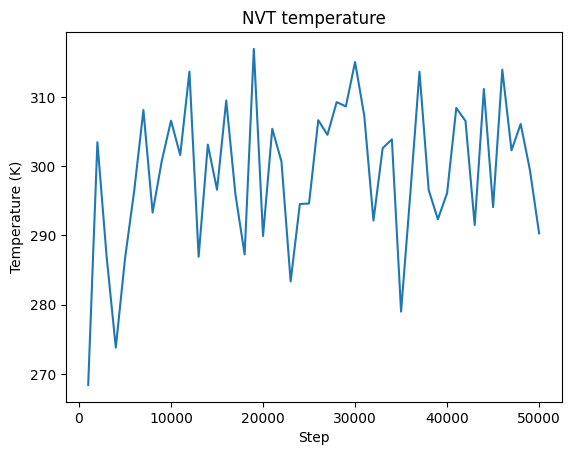

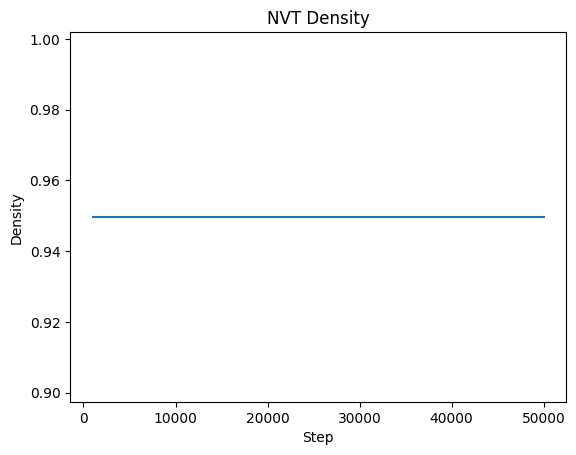

Average temperature:  300.5518031733298


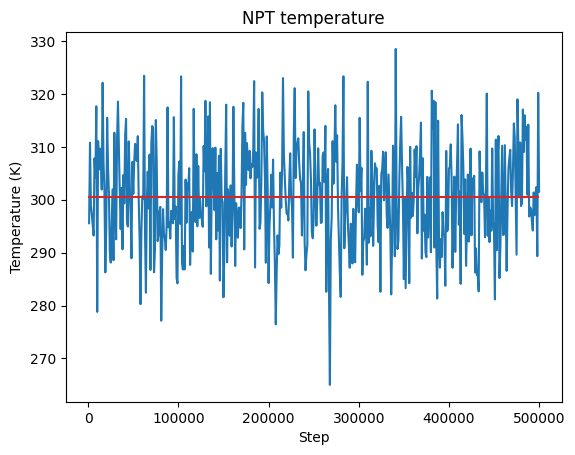

Average density:  0.9918361960655886


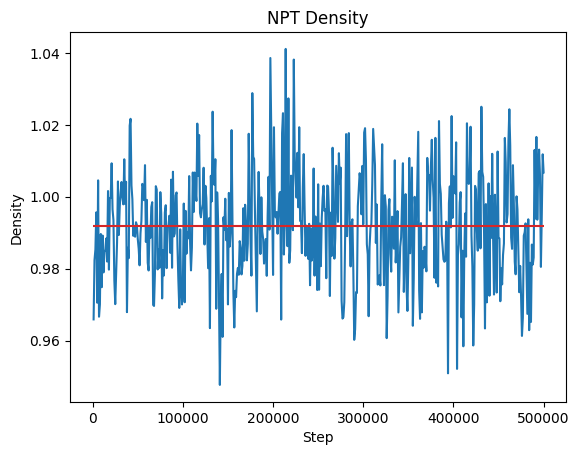

/usr/local/lib/python3.12/dist-packages/MDAnalysis/topology/PDBParser.py:372: UserWarning: Unknown element EP found for some atoms. These have been given an empty element record. If needed they can be guessed using universe.guess_TopologyAttrs(context='default', to_guess=['elements']).
  warnings.warn(wmsg)
/usr/local/lib/python3.12/dist-packages/MDAnalysis/coordinates/DCD.py:171: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


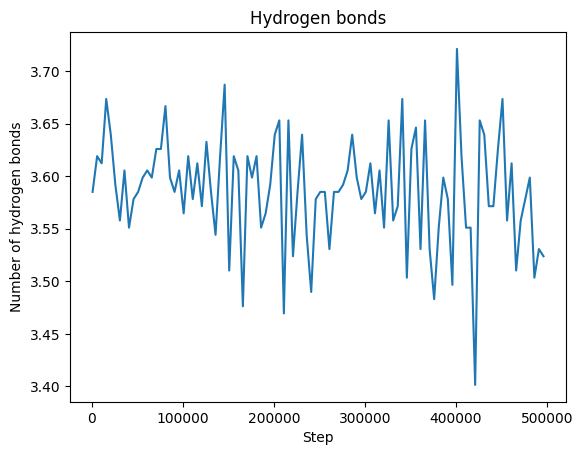

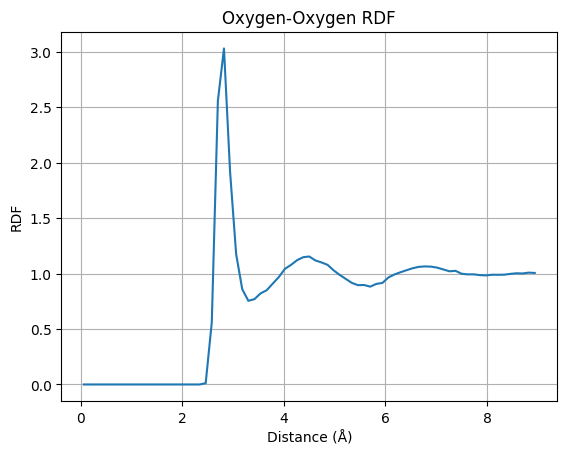

In [9]:
# Time for analysis!
import MDAnalysis as mda
from MDAnalysis.analysis.hydrogenbonds.hbond_analysis import HydrogenBondAnalysis as HBA # For Hbond analysis
import MDAnalysis.analysis.rdf as RDF # For RDF analysis
import numpy as np
import matplotlib.pyplot as plt

NVTdata = np.loadtxt("NVTOutput.txt", delimiter=',')

step = NVTdata[:,0]
potential_energy_nvt = NVTdata[:,1]
temperature_nvt = NVTdata[:,2]
vol_nvt = NVTdata[:,3]
density_nvt = NVTdata[:,4]


# plt.plot(step, potential_energy_nvt)
# plt.xlabel("Step")
# plt.ylabel("Potential energy (kJ/mol)")
# plt.title('NVT potential energy')
# plt.show()
plt.plot(step, temperature_nvt)
plt.xlabel("Step")
plt.ylabel("Temperature (K)")
plt.title('NVT temperature')

plt.show()
plt.plot(step, density_nvt)
plt.xlabel("Step")
plt.ylabel("Density")
plt.title('NVT Density')
plt.show()

#plt.plot(step, vol_nvt)
#plt.xlabel("Step")
#plt.ylabel("Volume")
#plt.title('NVT Volume')
#plt.show()

# Now the NPT
NPTdata = np.loadtxt("NPTOutput.txt", delimiter=',')
step = NPTdata[:,0]
potential_energy_npt = NPTdata[:,1]
temperature_npt = NPTdata[:,2]
density_npt = NPTdata[:,3]

plt.plot(step, temperature_npt)
# Add average
AvgT = np.array(temperature_npt).mean()
print('Average temperature: ', AvgT)
plt.hlines(AvgT, 0, step[-1], color='tab:red')
plt.xlabel("Step")
plt.ylabel("Temperature (K)")
plt.title('NPT temperature')
plt.show()

plt.plot(step, density_npt)
# Add average
AvgD = np.array(density_npt).mean()
print('Average density: ', AvgD)
plt.hlines(AvgD, 0, step[-1], color='tab:red')
plt.xlabel("Step")
plt.ylabel("Density")
plt.title('NPT Density')
plt.show()

# Load a topology and a trajectory
u = mda.Universe('EMoutput.pdb', 'NPToutput.dcd')



# Debugging bonds
bond_list = []

for res in u.residues:
    O = res.atoms.select_atoms("name O")
    H1 = res.atoms.select_atoms("name H1")
    H2 = res.atoms.select_atoms("name H2")

    if len(O) == 1 and len(H1) == 1 and len(H2) == 1:
        bond_list.append((O[0].index, H1[0].index))
        bond_list.append((O[0].index, H2[0].index))

u.add_bonds(bond_list)




# 1. Manually specify the hydrogen-containing atom group
h_selection = "(name H1 H2)"

# 2. Manually specify the acceptor atom group
acc_selection = "(name O)"

hbonds = HBA(universe=u, hydrogens_sel=h_selection, donors_sel=acc_selection,
             acceptors_sel=acc_selection, update_selections=False,
             d_a_cutoff=3.5, d_h_a_angle_cutoff=140)
hbonds.run()




# Number of H-bonds in each frame
counts = hbonds.count_by_time()

# Multiply by two, as each hydrogen bond is shared between two molecules.
plt.plot(step[::5], 2*counts/len(u.select_atoms("resname HOH and name O")) )
plt.xlabel("Step")
plt.ylabel("Number of hydrogen bonds")
plt.title('Hydrogen bonds')
plt.show()

# NOTE: From a Gromacs simulation (120 ns long), I get about 3.6 H-bonds/molecule


# H-bond analysis done (can do more in-depth, depending on time ...)
# Let's do RDF!

rdf = RDF.InterRDF(u.select_atoms("resname HOH and name O"), u.select_atoms("resname HOH and name O"), range=(0.0, 9.0), exclusion_block=(1, 1), density=False )
rdf.run()

plt.plot(rdf.results.bins, rdf.results.rdf)
plt.grid()
plt.xlabel("Distance (Å)")
plt.ylabel("RDF")
plt.title('Oxygen-Oxygen RDF')
plt.show()




